# Distribution of Returns Analysis

Run the price fetch step by step and visualize each transformation.
Set `ticker` and `timeframe` below.

In [1]:
import sys
from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path.cwd().parent / 'scripts'))

from dor import fetch_prices, save_results, drop_today_row, KEEP_COLUMNS

## Fetch and Manage Data

### 1. Fetch raw data

In [2]:
ticker = 'AAPL'
timeframe = 'd'  # d | w | m

df = fetch_prices(ticker, timeframe)
print(f'{len(df)} rows from {df.index.min().date()} to {df.index.max().date()}')
df.tail()

11441 rows from 1980-12-12 to 2026-05-06


,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
2026-04-30 00:00:00-04:00,270.500000,276.000000,268.140015,271.350006,271.350006,91848200,0.0,0.0
2026-05-01 00:00:00-04:00,278.859985,287.220001,278.369995,280.140015,280.140015,79915400,0.0,0.0
2026-05-04 00:00:00-04:00,279.660004,280.630005,274.859985,276.829987,276.829987,46668400,0.0,0.0
2026-05-05 00:00:00-04:00,276.929993,284.570007,276.500000,284.179993,284.179993,49101300,0.0,0.0
2026-05-06 00:00:00-04:00,281.915009,287.130005,281.075012,285.910095,285.910095,24607054,0.0,0.0


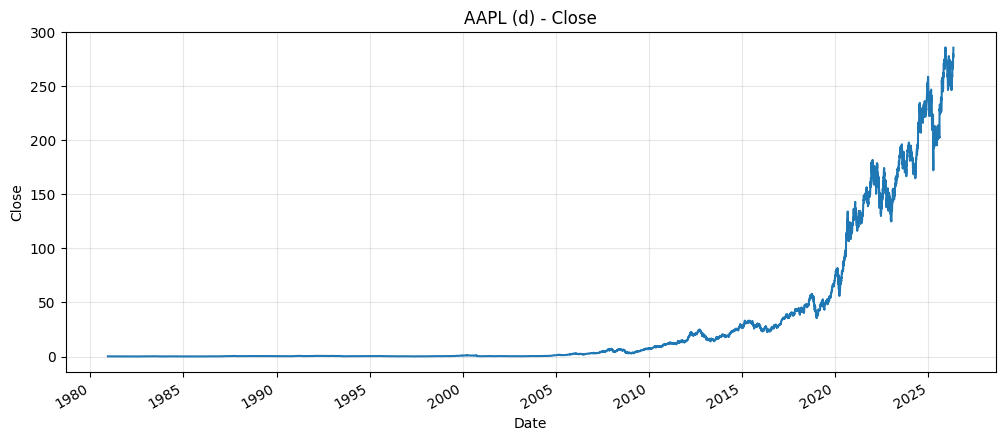

In [3]:
ax = df['Close'].plot(title=f'{ticker} ({timeframe}) - Close', figsize=(12, 5))
ax.set_ylabel('Close')
ax.grid(True, alpha=0.3)

### 2. Reformat the date index as `DD-MM-YY`

In [4]:
cleaned = df.copy()
cleaned.index = cleaned.index.strftime('%d-%m-%y')
cleaned.index.name = 'Date'
cleaned.head()

,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
Date,,,,,,,,
12-12-80,0.128348,0.128906,0.128348,0.128348,0.098298,469033600,0.0,0.0
15-12-80,0.122210,0.122210,0.121652,0.121652,0.093169,175884800,0.0,0.0
16-12-80,0.113281,0.113281,0.112723,0.112723,0.086331,105728000,0.0,0.0
17-12-80,0.115513,0.116071,0.115513,0.115513,0.088468,86441600,0.0,0.0
18-12-80,0.118862,0.119420,0.118862,0.118862,0.091032,73449600,0.0,0.0


### 3. Keep only the columns we need

In [5]:
cleaned = cleaned[KEEP_COLUMNS]
cleaned.head()

,Open,High,Low,Close,Adj Close
Date,,,,,
12-12-80,0.128348,0.128906,0.128348,0.128348,0.098298
15-12-80,0.122210,0.122210,0.121652,0.121652,0.093169
16-12-80,0.113281,0.113281,0.112723,0.112723,0.086331
17-12-80,0.115513,0.116071,0.115513,0.115513,0.088468
18-12-80,0.118862,0.119420,0.118862,0.118862,0.091032


### 4. Drop today's row if present

Today's bar is still forming, so its OHLC values aren't final. Drop it so all returns are computed from settled sessions only.

In [6]:
before = len(cleaned)
cleaned = drop_today_row(cleaned, timeframe)
print(f'Dropped {before - len(cleaned)} row(s). New size: {len(cleaned)} rows.')
cleaned.head()

Dropped 1 row(s). New size: 11440 rows.


,Open,High,Low,Close,Adj Close
Date,,,,,
12-12-80,0.128348,0.128906,0.128348,0.128348,0.098298
15-12-80,0.122210,0.122210,0.121652,0.121652,0.093169
16-12-80,0.113281,0.113281,0.112723,0.112723,0.086331
17-12-80,0.115513,0.116071,0.115513,0.115513,0.088468
18-12-80,0.118862,0.119420,0.118862,0.118862,0.091032


### 5. Sort from newest to oldest

The index is now a `DD-MM-YY` string, so a plain lexicographic sort would be wrong.
Parse the strings back to dates inside the sort to keep chronological order.

In [7]:
cleaned = cleaned.sort_index(
    ascending=False,
    key=lambda idx: pd.to_datetime(idx, format='%d-%m-%y'),
)
cleaned.head()

,Open,High,Low,Close,Adj Close
Date,,,,,
05-05-26,276.929993,284.570007,276.500000,284.179993,284.179993
04-05-26,279.660004,280.630005,274.859985,276.829987,276.829987
01-05-26,278.859985,287.220001,278.369995,280.140015,280.140015
30-04-26,270.500000,276.000000,268.140015,271.350006,271.350006
29-04-26,267.549988,271.040009,267.040009,270.170013,270.170013


### 6. C-C Returns (current Adj Close vs previous period's Adj Close)

Frame is newest-first, so the *previous* period sits in the row below — use `shift(-1)`.

In [8]:
prev_adj_close = cleaned['Adj Close'].shift(-1)
cleaned['C-C Returns'] = (cleaned['Adj Close'] - prev_adj_close) / prev_adj_close
cleaned[['Adj Close', 'C-C Returns']].head()

,Adj Close,C-C Returns
Date,,
05-05-26,284.179993,0.026551
04-05-26,276.829987,-0.011816
01-05-26,280.140015,0.032394
30-04-26,271.350006,0.004368
29-04-26,270.170013,-0.001995


### 7. H-L Returns (low to high of the period)

In [9]:
cleaned['H-L Returns'] = (cleaned['High'] - cleaned['Low']) / cleaned['Low']
cleaned[['High', 'Low', 'H-L Returns']].head()

,High,Low,H-L Returns
Date,,,
05-05-26,284.570007,276.500000,0.029186
04-05-26,280.630005,274.859985,0.020993
01-05-26,287.220001,278.369995,0.031792
30-04-26,276.000000,268.140015,0.029313
29-04-26,271.040009,267.040009,0.014979


### 8. O-C Returns (open to close) — daily only

Open-to-close only makes sense for daily bars. For weekly/monthly the "open" and "close" span many sessions, so the column is skipped.

In [10]:
if timeframe == 'd':
    cleaned['O-C Returns'] = (cleaned['Close'] - cleaned['Open']) / cleaned['Open']
    display(cleaned[['Open', 'Close', 'O-C Returns']].head())
else:
    print(f"Skipped O-C Returns: only added for daily data (current timeframe: '{timeframe}').")

,Open,Close,O-C Returns
Date,,,
05-05-26,276.929993,284.179993,0.026180
04-05-26,279.660004,276.829987,-0.010119
01-05-26,278.859985,280.140015,0.004590
30-04-26,270.500000,271.350006,0.003142
29-04-26,267.549988,270.170013,0.009793


### 9. Drop NaN rows

Only the oldest row should have a `NaN` (in `C-C Returns`, since there's no prior period). Verify the count, then drop it.

In [11]:
nan_per_col = cleaned.isna().sum()
rows_with_nan = cleaned.isna().any(axis=1).sum()
print(f'Rows with at least one NaN: {rows_with_nan}')
print('NaN per column:')
print(nan_per_col)

Rows with at least one NaN: 1
NaN per column:
Open           0
High           0
Low            0
Close          0
Adj Close      0
C-C Returns    1
H-L Returns    0
O-C Returns    0
dtype: int64


In [12]:
before = len(cleaned)
cleaned = cleaned.dropna()
print(f'Dropped {before - len(cleaned)} row(s). New size: {len(cleaned)} rows.')
cleaned.tail()

Dropped 1 row(s). New size: 11439 rows.


,Open,High,Low,Close,Adj Close,C-C Returns,H-L Returns,O-C Returns
Date,,,,,,,,
19-12-80,0.126116,0.126674,0.126116,0.126116,0.096588,0.061028,0.004425,0.000000
18-12-80,0.118862,0.119420,0.118862,0.118862,0.091032,0.028993,0.004694,0.000000
17-12-80,0.115513,0.116071,0.115513,0.115513,0.088468,0.024751,0.004831,0.000000
16-12-80,0.113281,0.113281,0.112723,0.112723,0.086331,-0.073398,0.004950,-0.004926
15-12-80,0.122210,0.122210,0.121652,0.121652,0.093169,-0.052171,0.004587,-0.004566


### 10. Save raw + cleaned CSVs and summary JSON

In [13]:
raw_csv_path, clean_csv_path, report_path, summary = save_results(ticker, timeframe, df)
summary

{'ticker': 'AAPL',
 'timeframe': 'd',
 'interval': '1d',
 'fetched_on': '2026-05-06',
 'rows': 11441,
 'start': '1980-12-12T00:00:00-05:00',
 'end': '2026-05-06T00:00:00-04:00',
 'raw_csv_path': 'raw-data/AAPL_d_2026-05-06.csv',
 'clean_csv_path': 'data/AAPL_d_2026-05-06.csv'}

## Descriptive Statistics

Compute Excel-style descriptive statistics on each returns column. We start with **C-C Returns**; the same recipe will be replicated for the other return columns afterwards.

Pandas defaults match Excel: `std`/`var` use `ddof=1`, `skew` is the bias-corrected G1, `kurt` is the bias-corrected excess kurtosis (G2), `sem` is `std / sqrt(n)`.

### C-C Returns — pick the column

Drop any leftover NaN (defensive — there shouldn't be any after step 9) and confirm what we're feeding into the stats.

In [14]:
cc = cleaned['C-C Returns'].dropna()
print(f'{len(cc)} observations')
cc.head()

11439 observations


Date
05-05-26    0.026551
04-05-26   -0.011816
01-05-26    0.032394
30-04-26    0.004368
29-04-26   -0.001995
Name: C-C Returns, dtype: float64

### Count, minimum, maximum, range

`count` is the number of non-NaN observations. `range` is just `max - min`.

In [15]:
count = int(cc.count())
minimum = cc.min()
maximum = cc.max()
rng = maximum - minimum

print(f'Count:    {count}')
print(f'Minimum:  {minimum:.6f}')
print(f'Maximum:  {maximum:.6f}')
print(f'Range:    {rng:.6f}')

Count:    11439
Minimum:  -0.518692
Maximum:  0.332280
Range:    0.850972


### Central tendency: mean, median, mode

`mode` follows Excel's `MODE` semantics: only return a value when at least one observation actually repeats. With floating-point returns nothing repeats, so the result is `None` — matching Excel's `#N/A`.

In [16]:
mean = cc.mean()
median = cc.median()
counts = cc.value_counts()
mode = float(counts.index[0]) if len(counts) > 0 and counts.iloc[0] > 1 else None

print(f'Mean:    {mean:.6f}')
print(f'Median:  {median:.6f}')
print(f'Mode:    {mode if mode is None else f"{mode:.6f}"}  (no value repeats — Excel MODE returns #N/A here)')

Mean:    0.001083
Median:  0.000000
Mode:    0.000000  (no value repeats — Excel MODE returns #N/A here)


### Dispersion: standard deviation, sample variance, standard error

All three use the **sample** estimator (`ddof=1`). Standard error is the standard error of the mean: `std / sqrt(n)` — pandas' `sem()` does that directly.

In [17]:
std = cc.std()
variance = cc.var()
sem = cc.sem()

print(f'Standard deviation: {std:.6f}')
print(f'Sample variance:    {variance:.6f}')
print(f'Standard error:     {sem:.6f}')

Standard deviation: 0.027575
Sample variance:    0.000760
Standard error:     0.000258


### Shape: skewness, kurtosis

Pandas' `skew()` is bias-corrected (Fisher-Pearson G1) and `kurt()` returns *excess* kurtosis (G2) — both match Excel's `SKEW` and `KURT`. A normal distribution has skewness ≈ 0 and excess kurtosis ≈ 0; positive kurtosis means fatter tails.

In [18]:
skewness = cc.skew()
kurtosis = cc.kurt()

print(f'Skewness: {skewness:.6f}')
print(f'Kurtosis: {kurtosis:.6f}  (excess; normal = 0)')

Skewness: -0.362042
Kurtosis: 18.694044  (excess; normal = 0)


### Combine via the helper

`descriptive_stats` in `dor.py` packages all of the above into a single dict so we can call it on any column. The values below should match what we computed cell-by-cell.

In [19]:
from dor import descriptive_stats

cc_stats = descriptive_stats(cleaned['C-C Returns'])
pd.Series(cc_stats, name='C-C Returns').to_frame()

,C-C Returns
mean,0.001083
standard_error,0.000258
median,0.000000
mode,0.000000
standard_deviation,0.027575
sample_variance,0.000760
kurtosis,18.694044
skewness,-0.362042
range,0.850972
minimum,-0.518692
